In [39]:
import numpy as np
import xarray as xr
from GB84 import variables, rho_m, v,cloud_heights, h_out, phi, f, non_dim_numbers
import matplotlib.pyplot as plt

In [33]:
cabaw = xr.open_mfdataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\data\Cabaw_radiometer\*.nc')
july = cabaw.sel(time=slice('2024-07-01', '2024-08-01'))

In [34]:
a = xr.open_mfdataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')

In [55]:
a

<xarray.Dataset>
Dimensions:          (time: 4464, day_in_time_interval: 31, nv: 2)
Coordinates:
  * time             (time) datetime64[ns] 2024-07-01 ... 2024-07-31T23:49:59...
Dimensions without coordinates: day_in_time_interval, nv
Data variables: (12/22)
    iso_dataset      |S1 ...
    product          |S1 ...
    station_details  |S1 ...
    date             (time) int32 dask.array<chunksize=(4464,), meta=np.ndarray>
    valid_dates      (day_in_time_interval) int8 dask.array<chunksize=(31,), meta=np.ndarray>
    time_bnds        (time, nv) datetime64[ns] dask.array<chunksize=(4464, 2), meta=np.ndarray>
    ...               ...
    F010             (time) float32 dask.array<chunksize=(4464,), meta=np.ndarray>
    IF010            (time) float32 dask.array<chunksize=(4464,), meta=np.ndarray>
    D010             (time) float32 dask.array<chunksize=(4464,), meta=np.ndarray>
    ID010            (time) float32 dask.array<chunksize=(4464,), meta=np.ndarray>
    TD002            (time) float32 dask.array<chunksize=(4464,), meta=np.ndarray>
    RH002            (time) float32 dask.array<chunksize=(4464,), meta=np.ndarray>
Attributes:
    institution:              Royal Netherlands Meteorological Institute (KNMI)
    comment:                  none
    Conventions:              CF-1.4
    location:                 CESAR observatory, the Netherlands
    file_creation_date_time:  20240826 10:49:12 (UTC)
    references:               cesar_surface_meteo_lc1_t10_v1.0.pdf @ http://w...
    history:                  Continuous observations are performed, gap fill...

In [35]:
T_surf = a.TA002.values
T_d_arr = a.TD002.values
p_surf = a.P0.values*100

In [36]:
july.lwp.sel(time = '2024-07-01T00:00:00.000000000').values

array(0.00327835, dtype=float32)

In [ ]:
dt = 600
X = np.zeros(len(T_surf))
X[0] = july.lwp.sel(time = '2024-07-01T00:00:00.000000000').values
for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = variables(T_0, T_d, p_0, obs=False).run()
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
    if i<(len(T_surf)-1):
        X[i+1] = X[i] + dt*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X[i])

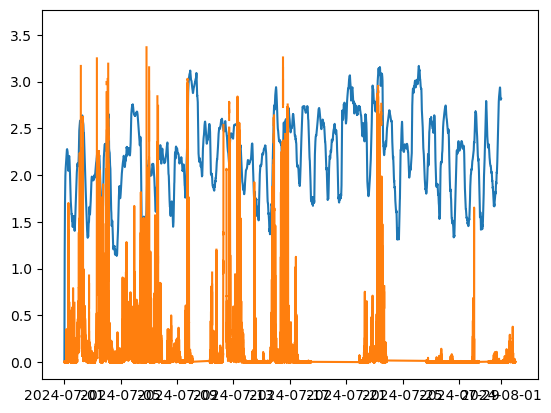

In [44]:
plt.plot(a.time,X)
plt.plot(july.time,july.lwp)

In [53]:
lwp_used = july.lwp.sel(time=a.time.values,method='nearest')
D = X - lwp_used
D_mean = D.mean()
D_var = 1/(len(D) - 1)*((D - D_mean)**2).sum()

In [54]:
Q = np.sqrt(D_var/2)
Q.values

array(0.32489175)